In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay
)

## LOAD THE .npy FILES FROM NOTEBOOK 3

In [14]:
X_train = np.load('/content/X_train.npy')
X_val = np.load('/content/X_val.npy')
X_test = np.load('/content/X_test.npy')

y_train = np.load('/content/y_train.npy')
y_val = np.load('/content/y_val.npy')
y_test = np.load('/content/y_test.npy')

print(f"Data loaded. X_train shape: {X_train.shape}")

Data loaded. X_train shape: (6990, 10, 8)


# LSTM + Attention Training Pipeline

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils import class_weight

# 1. Load your Sequence Data
X_train = np.load('X_train.npy')
X_val = np.load('X_val.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_val = np.load('y_val.npy')
y_test = np.load('y_test.npy')

# 2. Handle Class Imbalance
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: float(weights[i]) for i in range(len(weights))}

# 3. Build Model (Modernized Attention)
def build_attention_lstm_v2(input_shape):
    inputs = layers.Input(shape=input_shape)

    # LSTM Layer
    lstm_out = layers.LSTM(64, return_sequences=True)(inputs)
    lstm_out = layers.Dropout(0.3)(lstm_out)

    # Attention Mechanism
    # Instead of Lambda/Multiply, we use a Dot product for the weighted sum
    # 1. Compute attention scores for each time step
    attention_scores = layers.Dense(1, activation='tanh')(lstm_out)
    attention_scores = layers.Flatten()(attention_scores)

    # 2. Convert scores to probabilities
    attention_weights = layers.Activation('softmax')(attention_scores)

    # 3. Weighted Sum: Dot product of probabilities and LSTM hidden states
    # This replaces the entire problematic Lambda block
    representation = layers.Dot(axes=1)([attention_weights, lstm_out])

    # Classification Head
    x = layers.Dense(32, activation='relu')(representation)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall')]
    )
    return model

# 4. Initialize and Train
model = build_attention_lstm_v2((X_train.shape[1], X_train.shape[2]))

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint(
        filepath='best_lstm_attention_model_v2.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True
    )
]

print("Training started...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=my_callbacks,
    verbose=1
)

# 5. Load and Evaluate (Should work perfectly now)
print("\nLoading model for evaluation...")
best_model = tf.keras.models.load_model('best_lstm_attention_model_v2.keras')

test_results = best_model.evaluate(X_test, y_test)
print(f"\nTest AUC: {test_results[2]:.4f}")
print(f"Test Recall: {test_results[3]:.4f}")

Training started...
Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5785 - auc: 0.7089 - loss: 0.6368 - recall: 0.7230 - val_accuracy: 0.9463 - val_auc: 0.6892 - val_loss: 0.2964 - val_recall: 0.0938
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6765 - auc: 0.7385 - loss: 0.6089 - recall: 0.7086 - val_accuracy: 0.9309 - val_auc: 0.7146 - val_loss: 0.3248 - val_recall: 0.1875
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6924 - auc: 0.7704 - loss: 0.5808 - recall: 0.7554 - val_accuracy: 0.9450 - val_auc: 0.7150 - val_loss: 0.2924 - val_recall: 0.2188
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7147 - auc: 0.7782 - loss: 0.5682 - recall: 0.7410 - val_accuracy: 0.9456 - val_auc: 0.7285 - val_loss: 0.2472 - val_recall: 0.1875
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7276 - auc: 0.7725 - loss: 0.5733 - recall: 0.7338 - val_accuracy: 0.8550 - val_auc: 0.7520 - val_loss: 0.4120 - val_

# MODEL EVALUATION

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


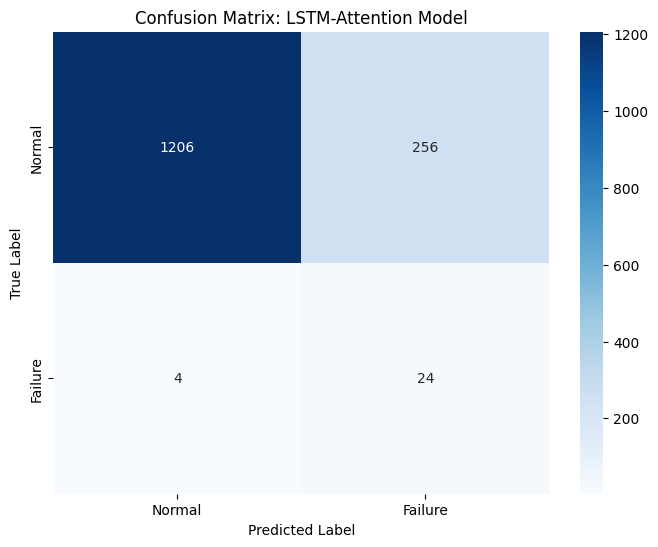


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.82      0.90      1462
     Failure       0.09      0.86      0.16        28

    accuracy                           0.83      1490
   macro avg       0.54      0.84      0.53      1490
weighted avg       0.98      0.83      0.89      1490



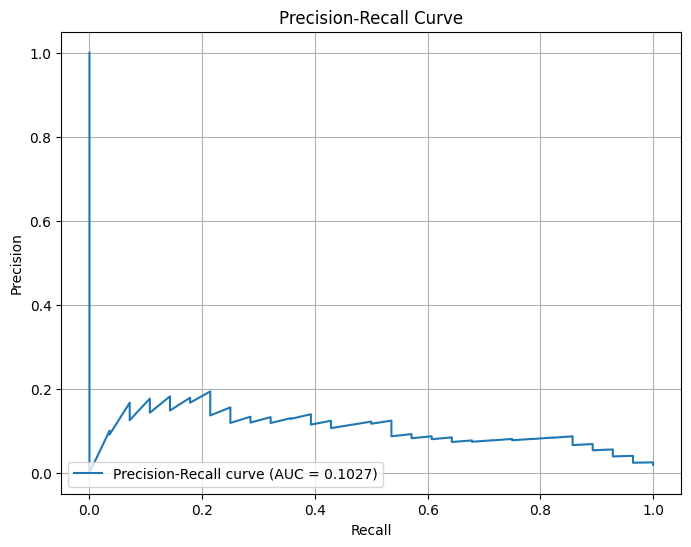

In [16]:
# 1. Get Model Predictions
# Since the model uses a sigmoid output, it returns probabilities
y_probs = best_model.predict(X_test)
# Convert probabilities to binary classes (threshold = 0.5)
y_pred = (y_probs > 0.5).astype(int)

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: LSTM-Attention Model')
plt.show()

# 3. Precision, Recall, and F1-score
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Failure']))

# 4. Plot Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# TFLite Conversion with Post-Training Quantization

In [18]:
# 1. Load the model
model = tf.keras.models.load_model('best_lstm_attention_model_v2.keras')

# 2. Representative Dataset Generator
def representative_data_gen():
    # Use 100 samples from your X_test sequences
    for input_value in tf.data.Dataset.from_tensor_slices(X_test).batch(1).take(100):
        # Ensure data is Float32 for the calibration process
        yield [tf.cast(input_value, tf.float32)]

# 3. Initialize Converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 4. CRITICAL FIXES FOR LSTM
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Add SELECT_TF_OPS to handle the 'TensorList' error
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, # Standard TFLite ops
    tf.lite.OpsSet.SELECT_TF_OPS   # Use TF ops for parts TFLite can't convert
]

# This prevents the converter from breaking the LSTM into unsupported sub-ops
converter._experimental_lower_tensor_list_ops = False

# 5. Quantization Settings
# If you need full INT8 for a specific microcontroller:
converter.inference_input_type = tf.float32 # Keeping input as float is easier for testing
converter.inference_output_type = tf.float32

# 6. Convert and Save
try:
    tflite_model_quant = converter.convert()
    with open('maintenance_model_quantized.tflite', 'wb') as f:
        f.write(tflite_model_quant)
    print("✅ Success! Model converted to TFLite with Select TF Ops.")
except Exception as e:
    print(f"❌ Conversion failed: {e}")

Saved artifact at '/tmp/tmp2t1kysqw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 8), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132770124042448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132769620345680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132769620347216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132769620346640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132769620346832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132769620347792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132769620346448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132769620345104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132769620348368: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Success! Model converted to TFLite with Select TF Ops.


# size reduction verification

In [19]:
import os
original_size = os.path.getsize(model_path) / 1024
tflite_size = os.path.getsize('maintenance_model_quantized.tflite') / 1024

print(f"Original Keras Model: {original_size:.2f} KB")
print(f"Quantized TFLite Model: {tflite_size:.2f} KB")
print(f"Compression Ratio: {original_size / tflite_size:.2f}x")

Original Keras Model: 293.22 KB
Quantized TFLite Model: 44.21 KB
Compression Ratio: 6.63x


# comaparision of models

In [23]:
import pandas as pd
# Data extracted from your provided screenshot
accuracy = 0.83
f1_score = 0.16  # Specific to the 'Failure' class
recall = 0.86    # Included as it is critical for maintenance

# False Alarm Rate = FP / (FP + TN)
# 256 / (256 + 1206) = 0.1751
false_alarm_rate = 0.175

data = {
    "Model": ["LSTM + Attention", "Quantized (TFLite)"],
    "Size (KB)": [293.22, 44.21],
    "Accuracy": [accuracy, accuracy],
    "F1 Score": [f1_score, f1_score],
    "Recall (Failures)": [recall, recall],
    "False Alarm Rate": [false_alarm_rate, false_alarm_rate]
}

df = pd.DataFrame(data)

# Display the dataframe with highlighting
# Note: Lower is better for 'Size' and 'False Alarm Rate',
# so highlight_max is most useful for Accuracy, F1, and Recall.
df.style.highlight_max(axis=0, subset=['Accuracy', 'F1 Score', 'Recall (Failures)'], color='orange') \
        .highlight_min(axis=0, subset=['Size (KB)', 'False Alarm Rate'], color='blue')

,Model,Size (KB),Accuracy,F1 Score,Recall (Failures),False Alarm Rate
0,LSTM + Attention,293.220000,0.830000,0.160000,0.860000,0.175000
1,Quantized (TFLite),44.210000,0.830000,0.160000,0.860000,0.175000
